# Satisfaction Predictors for Business Class Flyers


### Introduction

The airline industry is an interesting paradox: it requires massive capital infrastructure yet operates on razor-thin margins that are well below most other sectors. While typical S&P 500 companies maintain net profit margins between 12–13% ([Factset Insight](https://insight.factset.com/sp-500-reporting-net-profit-margin-above-5-year-average-for-6th-straight-quarter)), the global airline industry is forecasted to achieve a margin of just 3.6% in 2025 ([IATA](https://www.iata.org/en/pressroom/2024-releases/2024-06-03-01/)). Even the most profitable carriers, which may post billions in topline revenue, are often one fuel price spike or operational failure away from losses.

By analyzing this [Airline Passenger Satisfaction](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction/data) dataset from Kaggle, I aim to explore how airlines generate value and identify actionable opportunities to increase profitability while enhancing the customer experience.

In this analysis, I propose that targeted investment in digital infrastructure for Business Class travelers, who represent just 12% of passengers but generate up to 75% of profits ([Investopedia](https://www.investopedia.com/ask/answers/041315/how-much-revenue-airline-industry-comes-business-travelers-compared-leisure-travelers.asp)), is the most effective mechanism for sustainable growth.

In [69]:
### Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle


In [7]:
# Load cleaned data
df = pd.read_csv("../datasets/processed/cleaned_data.csv")
display(df.head())

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,type
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,4,3,4,4,5,5,25,18.0,neutral or dissatisfied,train
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,5,3,1,4,1,1,6.0,neutral or dissatisfied,train
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,4,3,4,4,4,5,0,0.0,satisfied,train
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,5,3,1,4,2,11,9.0,neutral or dissatisfied,train
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,4,4,3,3,3,0,0.0,satisfied,train


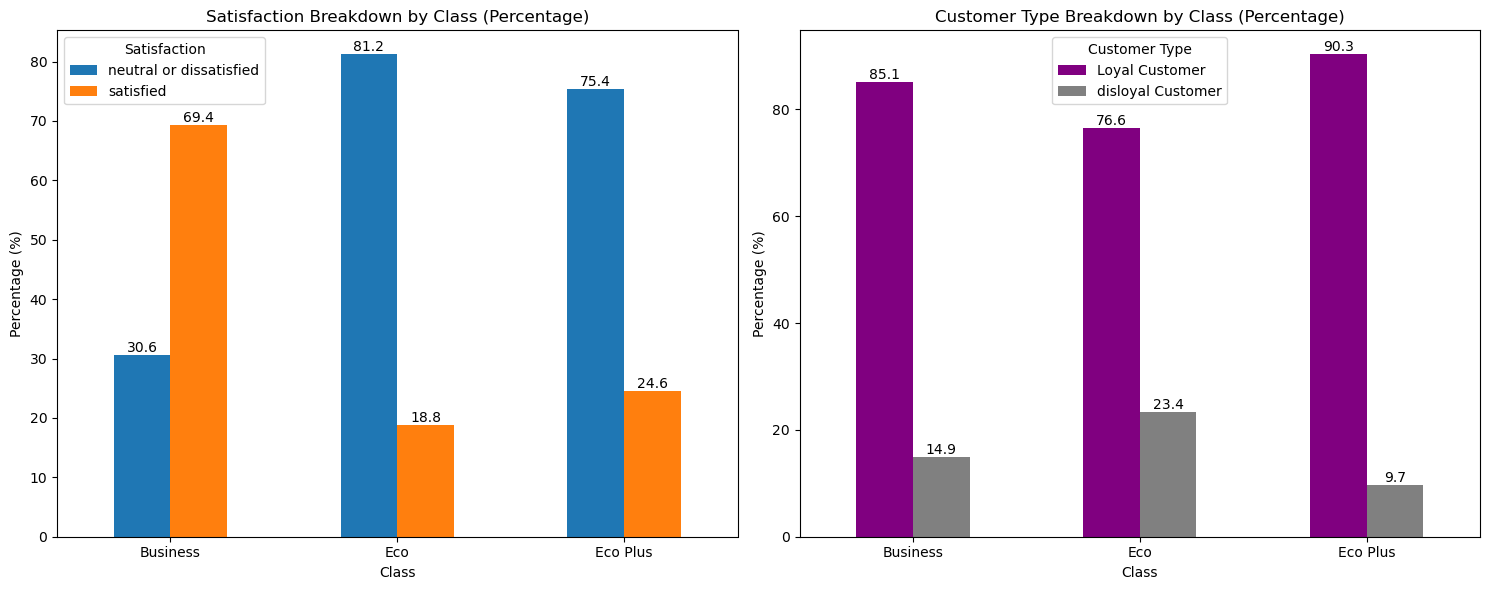

In [32]:
# Plot Satisfaction Breakdown by Class
satisfaction_counts = pd.crosstab(df['Class'], df['satisfaction'])
satisfaction_pct = (pd.crosstab(df['Class'], df['satisfaction'], normalize='index') * 100).round(1)

# Plot Loyalty Breakdown by Class
loyal_counts = pd.crosstab(df['Class'], df['Customer Type'])
loyal_pct = (pd.crosstab(df['Class'], df['Customer Type'], normalize='index') * 100).round(1)


fig, ax = plt.subplots(1, 2, figsize=(15, 6))
satisfaction_pct.plot(kind='bar', ax=ax[0])
ax[0].bar_label(ax[0].containers[0])
ax[0].bar_label(ax[0].containers[1])
ax[0].set_title('Satisfaction Breakdown by Class (Percentage)')
ax[0].set_xlabel('Class')
ax[0].set_ylabel('Percentage (%)')
ax[0].legend(title='Satisfaction')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)


loyal_pct.plot(kind='bar', ax=ax[1], color=['purple', 'grey'])
ax[1].bar_label(ax[1].containers[0])
ax[1].bar_label(ax[1].containers[1])
ax[1].set_title('Customer Type Breakdown by Class (Percentage)')
ax[1].set_xlabel('Class')
ax[1].set_ylabel('Percentage (%)')
ax[1].legend(title='Customer Type')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

The data reveals a stark contrast in satisfaction: 69.4% of Business Class passengers are satisfied, compare to just 18.8% seen in Economy. This could be attributed the superior physical comfort of premium cabins.

However, satisfaction does not guarantee retention. Surprisingly, Business Class passengers show a lower loyalty rate (85.1%) compared to Economy Plus travelers (90.3%). This suggests that physical comfort alone is insufficient to lock in premium customers. If seats and food aren't the primary drivers of retention for this segment, what is?

To answer this, I turned to machine learning to uncover the hidden predictors of passenger satisfaction.

(Check out [01_cleaning_and_prep.ipynb](../technical_analysis/01_cleaning_and_prep.ipynb) for more details)

### Expectation Gap

In [68]:
# Load the baseline model
baseline_model_data = pickle.load(open('../models/baseline_model.pkl', 'rb'))
print(f'Baseline Model loaded with an accuracy of {(baseline_model_data['accuracy'] * 100):.1f}%')

Baseline Model loaded with an accuracy of 96.2%


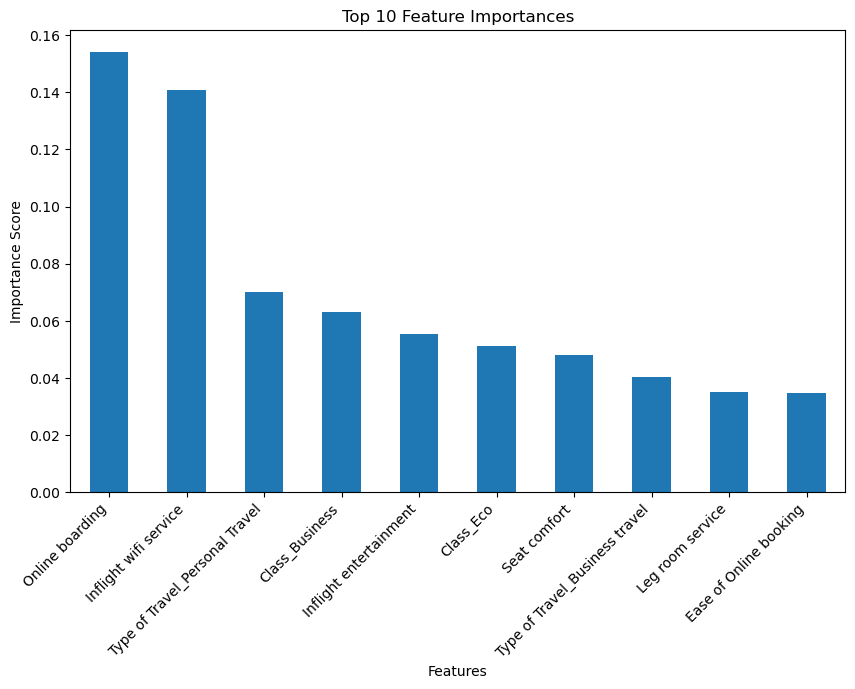

In [67]:
baseline_importance = pd.DataFrame({'Feature': baseline_model_data['feature_names'], 'Importance': baseline_model_data['importance']}).sort_values(by='Importance', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))

baseline_importance.plot.bar(x='Feature', y='Importance', ax=ax)
ax.set_title('Top 10 Feature Importances')
ax.set_xlabel('Features')
ax.set_ylabel('Importance Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend().remove()

plt.show()

To understand the drivers of satisfaction without human bias, I established a **Baseline Random Forest Model** with an accurary of 96.2%. 
Unlike linear models, a Random Forest can detect complex, non-linear relationships (e.g., satisfaction might drop off sharply only after a delay exceeds 30 minutes). I fed the model the raw passenger data with demographics, flight details, and survey scores, then asked it to rank features by their predictive power. 

Suprisingly, the model flagged `Online Boarding` as the #1 predictor of satisfaction, toping `Seat Comfort` and `Leg Room Service`. 

(Check out [04_final_model_evaluation.ipynb](../technical_analysis/04_final_model_evaluation.ipynb) for more details)

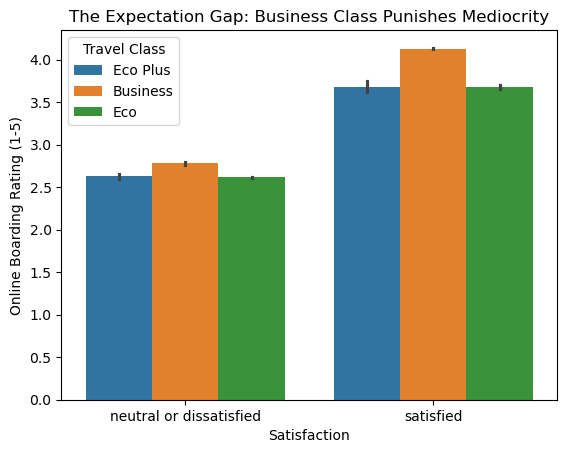

In [79]:
fig, ax = plt.subplots()
sns.barplot(data=df, y='Online boarding', x='satisfaction', hue='Class', ax=ax)
ax.set_title("The Expectation Gap: Business Class Punishes Mediocrity")
ax.set_ylabel("Online Boarding Rating (1-5)")
ax.set_xlabel("Satisfaction")
ax.legend(title='Travel Class')
plt.show()

Why would a 5-minute administrative task matter more than a 6-hour physical experience? The chart above exposes the mechanism behind the model's finding: The "Digital Handshake"

Economy passengers (Green/Blue bars) remain relatively satisfied even with a "Average" (3/5) boarding experience. On the otherhand, Business Class passengers (Purple bar) have higher expectations. It takes a digital boarding experience of at least a 4/5 to be satisfied.

The data shows that the "Digital Handshake" (App, Check-in, Boarding) may not just be a convenience, but a prerequisit for an enjoyable trip.

### Digital vs Physical Comfort

### Customer Validation